# 📘 S8_P3 (corrigé) — KMeans vs DBSCAN : le match sur les « moons »

## 🎯 L'objectif : montrer où KMeans ÉCHOUE et DBSCAN RÉUSSIT

Le dataset **`make_moons`** génère deux **croissants entrelacés** — des formes allongées, pas rondes. C'est le test parfait pour révéler la différence fondamentale entre les deux algorithmes :
- **KMeans** ne sait faire que des clusters **ronds** → il va couper les croissants n'importe comment.
- **DBSCAN** regroupe par **densité** → il épouse la forme des croissants.

---
Imports + génération de 500 points en 2 croissants (`noise=0.2`).

In [39]:
import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons 
from sklearn.cluster import KMeans, DBSCAN
import pandas as pd
import plotly.express as px

In [55]:
X_moons, _ = make_moons(500, noise=0.2, random_state=32)

Visualisation des données brutes : tu vois les **deux croissants** entrelacés. C'est CETTE forme que les algorithmes vont tenter de retrouver.

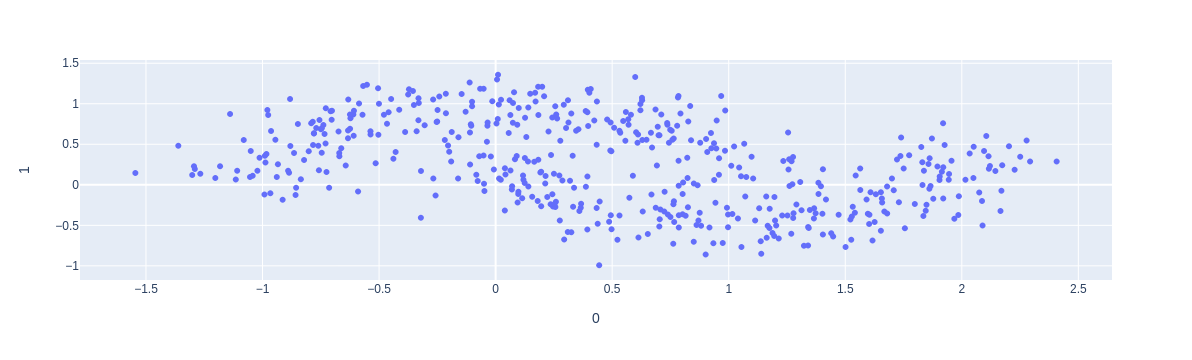

In [56]:
px.scatter(pd.DataFrame(X_moons), x = 0, y = 1)

## 🧠 THÉORIE — KMeans : le clustering par centres

L'algorithme le plus classique. On lui donne **le nombre de clusters `k`** à trouver, et il procède ainsi :
1. Place k **centres** (centroïdes) au hasard,
2. Assigne chaque point au centre le plus proche,
3. Déplace chaque centre au milieu de ses points,
4. Répète 2-3 jusqu'à stabilité.

`kmeans.fit_predict(X)` renvoie le **numéro de cluster** (0, 1, 2…) de chaque point.

**⚠️ Deux limites à connaître :**
- Il faut **choisir k à l'avance** (d'où la « méthode du coude » et la silhouette, plus loin).
- KMeans ne fait que des clusters **ronds/sphériques** — il échoue sur des formes allongées ou entrelacées (tu le verras sur le dataset « moons »).

On demande `n_clusters=2` (on sait qu'il y a 2 croissants).

In [57]:
kmeans = KMeans(n_clusters=2, random_state=32).fit(X_moons)

/home/ccanodom/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [58]:
moons = pd.DataFrame(X_moons)

In [59]:
moons

,0,1
0,0.908029,0.403308
1,0.446365,-0.204997
2,-0.536928,0.659497
3,0.723553,-0.330614
4,-0.848218,0.748995
...,...,...
495,1.203708,-0.502793
496,0.332429,-0.271825
497,1.471634,-0.370667
498,0.647236,0.555620


In [60]:
kmeans.labels_

array([1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,

On assemble les points et leurs labels KMeans dans un DataFrame pour la visualisation.

In [61]:
results_df = pd.concat([moons, pd.Series(kmeans.labels_, name="kmeans")], axis = 1
         )

## 🔍 Le résultat KMeans : l'ÉCHEC attendu

Regarde : KMeans coupe les deux croissants par une frontière **quasi droite**, mélangeant les deux formes. Il ne peut faire que des blocs ronds autour de ses 2 centres → il ne « voit » pas les croissants. C'est sa limite fondamentale.

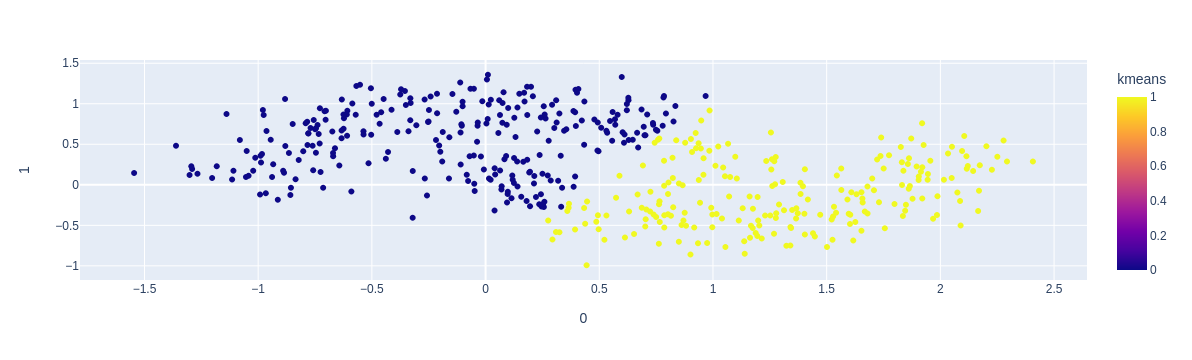

In [62]:
px.scatter(results_df, x = 0, y = 1, color="kmeans")

In [63]:
kmeans.cluster_centers_

array([[-0.14021152,  0.55923907],
       [ 1.29423602, -0.12342814]])

## 🧠 THÉORIE — DBSCAN : le clustering par DENSITÉ

Une approche radicalement différente de KMeans :
- **Pas besoin de choisir k** ! DBSCAN trouve tout seul le nombre de clusters.
- Il regroupe les points **densément entassés**, et marque les points isolés comme **bruit** (label **−1**).
- Il gère les formes **arbitraires** (allongées, entrelacées) là où KMeans échoue.

**Deux paramètres :**
- **`eps`** : le rayon de voisinage — deux points à moins de `eps` sont « voisins ».
- **`min_samples`** : le nombre minimum de voisins pour former un cœur de cluster.

`fit_predict` renvoie les labels ; `np.unique(labels)` montre les clusters trouvés (dont le `-1` = bruit).

**⚠️ DBSCAN est très sensible à `eps`** : trop petit → tout devient du bruit / plein de mini-clusters ; trop grand → tout fusionne en un seul bloc. Le bon réglage se cherche (souvent après standardisation).

`DBSCAN(eps=0.1)` sur les moons. Pas de `n_clusters` à fournir : il découvre les groupes tout seul.

In [64]:
labels_DB = DBSCAN(eps = 0.1).fit_predict(X_moons)

In [65]:
results_df = pd.concat([results_df, pd.Series(labels_DB, name="DBSCAN")], axis = 1
         )

In [66]:
results_df

,0,1,kmeans,DBSCAN
0,0.908029,0.403308,1,0
1,0.446365,-0.204997,1,7
2,-0.536928,0.659497,0,1
3,0.723553,-0.330614,1,2
4,-0.848218,0.748995,0,1
...,...,...,...,...
495,1.203708,-0.502793,1,5
496,0.332429,-0.271825,0,7
497,1.471634,-0.370667,1,5
498,0.647236,0.555620,0,0


## 🔍 Le résultat DBSCAN : la RÉUSSITE

Cette fois, chaque **croissant** est correctement identifié comme un cluster distinct (avec éventuellement quelques points de bruit en `-1`). DBSCAN a suivi la **densité** des points le long de chaque croissant.

## 📝 Résumé — la leçon centrale du clustering
| | KMeans | DBSCAN |
|---|---|---|
| Nombre de clusters | à fournir | automatique |
| Formes | rondes seulement | quelconques |
| Points isolés | forcés dans un cluster | marqués « bruit » (−1) |
| Sur les moons | ❌ échoue | ✅ réussit |

Aucun n'est « meilleur » dans l'absolu : KMeans est rapide et simple pour des groupes ronds ; DBSCAN gère les formes complexes et le bruit. On choisit selon les données.

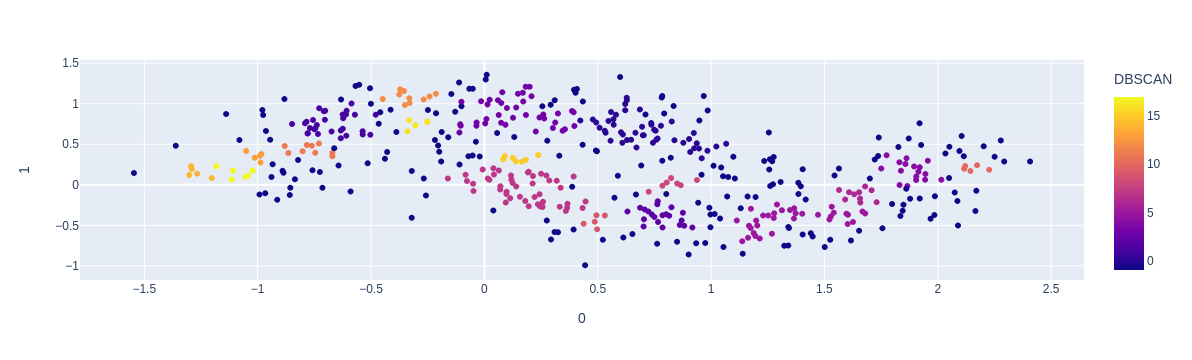

In [67]:
px.scatter(results_df, x = 0, y = 1, color="DBSCAN")